In [ ]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")


In [ ]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


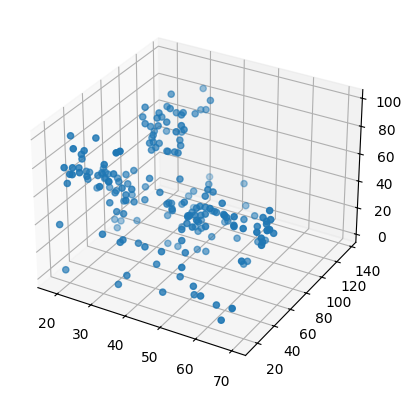

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(df['Age'],df['Annual Income (k$)'],df['Spending Score (1-100)'])



In [ ]:
x = df.iloc[:,2:].values
x

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

0.3319705845155097
0.335580238662684
0.40546302077733304
0.3575963460506624
0.4155672337697055
0.4420336177238127
0.43280878015743623
0.4092704336279867
0.39682188832916687
0.3712567648762146
0.37244233853816694
0.36119071776696293
0.3519198529999457


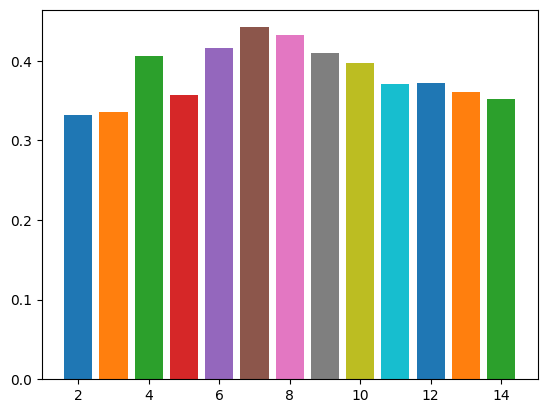

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss = [] # to save wcss values
k = range(2,15)

for i in k:
  model_wcss = KMeans(n_clusters = i,random_state = 42)
  model_wcss.fit(x)
  y_wcss = model_wcss.predict(x)
  wcss.append(model_wcss.inertia_)
  plt.bar(i,silhouette_score(x,y_wcss))
  print(silhouette_score(x,y_wcss))

In [ ]:
model = KMeans(n_clusters = 6,random_state =0)
model.fit(x)
y = model.predict(x)
y

array([2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 0, 5, 2, 5,
       2, 5, 0, 4, 4, 4, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 0, 4,
       0, 0, 4, 4, 0, 0, 0, 0, 0, 4, 0, 4, 4, 0, 0, 4, 0, 0, 4, 0, 0, 4,
       4, 0, 0, 4, 0, 4, 4, 4, 0, 4, 0, 4, 4, 0, 0, 4, 0, 4, 0, 0, 0, 0,
       0, 4, 4, 4, 4, 4, 0, 0, 0, 0, 4, 4, 4, 1, 4, 1, 4, 1, 3, 1, 3, 1,
       4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 4, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
import numpy as np
np.unique(y,return_counts = True)



(array([0, 1, 2, 3, 4, 5], dtype=int32), array([44, 39, 22, 34, 38, 23]))

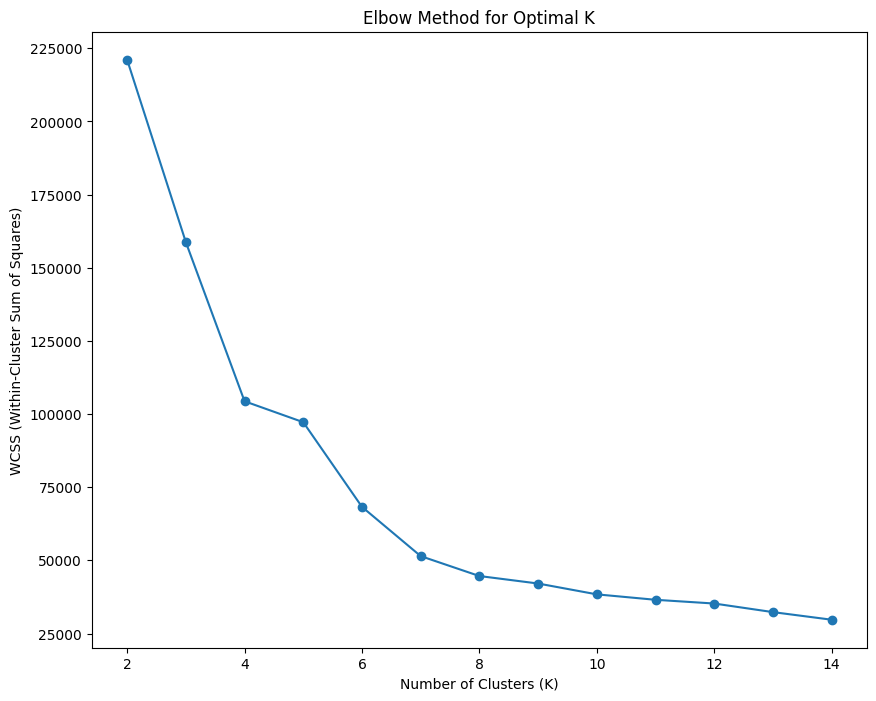

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(k, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

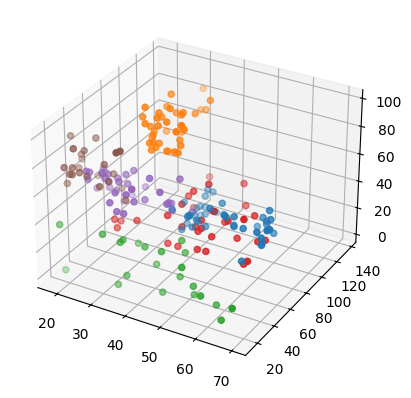

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
for i in range(6):
  ax.scatter(x[ y == i,0],x[y==i,1],x[y==i,2])
ax.scatter(model.cluster_centers_[:,0],
           model.cluster_centres_[:,1],
           model.cluster_centers_[:,2], s = 200,)